# Used Cars Dataset

| Column Name         | Description |
|---------------------|-------------|
| `car_name`          | Full name of the car, including the brand and model. |
| `brand`             | Brand (manufacturer) of the car. |
| `model`             | Specific model name of the car. |
| `seller_type`       | Type of seller offering the used car for sale. |
| `fuel_type`         | Type of fuel used by the car. |
| `transmission_type` | Type of transmission used by the car (e.g., Manual or Automatic). |
| `vehicle_age`       | Age of the vehicle in years since purchase. |
| `mileage`           | Fuel efficiency of the car (kilometers per liter). |
| `engine`            | Engine displacement in cubic centimeters (cc). |
| `max_power`         | Maximum engine power produced, measured in brake horsepower (BHP). |
| `seats`             | Total number of seats in the car. |
| `selling_price`     | Selling price of the used car (target variable). |

## Model Performans Karşılaştırması

AdaBoostRegressor modelinin performansı, üç farklı veri ön işleme stratejisi kullanılarak değerlendirilmiştir. Aşağıdaki tabloda, temel model ile hiperparametre optimizasyonu sonucunda elde edilen modelin performansları karşılaştırılmaktadır.


| Experiment | Preprocessing | Baseline R² | Tuned R² | Improvement |
|------------|---------------|------------:|---------:|------------:|
| 1 | No preprocessing | **62.23%** | **83.51%** | **+21.28** |
| 2 | `log1p` transformation on the target variable | **81.57%** | **89.27%** | **+7.70** |
| 3 | `PowerTransformer (Yeo-Johnson)` on numerical features | **62.19%** | **80.22%** | **+18.03** |

In [1554]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from math import ceil

pd.set_option("display.float_format", "{:.2f}".format)
plt.rcParams["figure.figsize"] = (16, 8)
sns.set_style("darkgrid")
warnings.filterwarnings("ignore")

In [1555]:
df = pd.read_csv("17-cardekho.csv")

In [1556]:
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [1557]:
# The "Unnamed: 0" kolonu veriyi dışa aktarırken oluşmuştur.
# Model için herhangi bir anlam ifade etmediği için veri setinden kaldırılmıştır.

df.drop("Unnamed: 0", axis= 1, inplace= True)

In [1558]:
print(f"Shape : {df.shape}")

Shape : (15411, 13)


In [1559]:
df.describe()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.00,15411.00,15411.00,15411.00,15411.00,15411.00,15411.00
mean,6.04,55616.48,19.70,1486.06,100.59,5.33,774971.12
std,3.01,51618.55,4.17,521.11,42.97,0.81,894128.36
min,0.00,100.00,4.00,793.00,38.40,0.00,40000.00
25%,4.00,30000.00,17.00,1197.00,74.00,5.00,385000.00
50%,6.00,50000.00,19.67,1248.00,88.50,5.00,556000.00
75%,8.00,70000.00,22.70,1582.00,117.30,5.00,825000.00
max,29.00,3800000.00,33.54,6592.00,626.00,9.00,39500000.00


In [1560]:
df[df["seats"] == 0]

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
3217,Honda City,Honda,City,18,40000,Individual,Petrol,Manual,13.00,1493,100.00,0,115000
12619,Nissan Kicks,Nissan,Kicks,2,10000,Individual,Diesel,Manual,19.39,1461,108.49,0,1154000


In [1561]:
df = df[df["seats"] != 0]

In [1562]:
df.dtypes

car_name              object
brand                 object
model                 object
vehicle_age            int64
km_driven              int64
seller_type           object
fuel_type             object
transmission_type     object
mileage              float64
engine                 int64
max_power            float64
seats                  int64
selling_price          int64
dtype: object

In [1563]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15409 entries, 0 to 15410
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   car_name           15409 non-null  object 
 1   brand              15409 non-null  object 
 2   model              15409 non-null  object 
 3   vehicle_age        15409 non-null  int64  
 4   km_driven          15409 non-null  int64  
 5   seller_type        15409 non-null  object 
 6   fuel_type          15409 non-null  object 
 7   transmission_type  15409 non-null  object 
 8   mileage            15409 non-null  float64
 9   engine             15409 non-null  int64  
 10  max_power          15409 non-null  float64
 11  seats              15409 non-null  int64  
 12  selling_price      15409 non-null  int64  
dtypes: float64(2), int64(5), object(6)
memory usage: 1.6+ MB


In [1564]:
df.isnull().sum()

car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

In [1565]:
df.duplicated().sum()

np.int64(167)

In [1566]:
duplicates = df[df.duplicated(keep= False)].sort_values(by= "car_name")
duplicates

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
10098,Audi A4,Audi,A4,5,51000,Dealer,Diesel,Automatic,18.25,1968,187.74,5,1850000
10492,Audi A4,Audi,A4,5,51000,Dealer,Diesel,Automatic,18.25,1968,187.74,5,1850000
3585,Audi A4,Audi,A4,9,68370,Dealer,Diesel,Automatic,17.11,1968,174.33,5,1345000
13469,Audi A4,Audi,A4,9,68370,Dealer,Diesel,Automatic,17.11,1968,174.33,5,1345000
10315,BMW 5,BMW,5,0,2000,Dealer,Diesel,Automatic,22.48,1995,187.74,5,4850000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12880,Volkswagen Polo,Volkswagen,Polo,4,55000,Dealer,Petrol,Manual,16.20,1199,74.00,5,675000
11517,Volkswagen Vento,Volkswagen,Vento,7,55000,Dealer,Diesel,Manual,22.27,1498,108.60,5,375000
11422,Volkswagen Vento,Volkswagen,Vento,7,55000,Dealer,Diesel,Manual,22.27,1498,108.60,5,375000
8948,Volkswagen Vento,Volkswagen,Vento,2,10000,Dealer,Petrol,Automatic,18.19,1197,103.20,5,1150000


In [1567]:
df.drop_duplicates(keep= "first", inplace= True)

In [1568]:
duplicates = df[df.duplicated(keep= False)].sort_values(by= "car_name")
duplicates

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price


In [1569]:
df.columns.to_list()

['car_name',
 'brand',
 'model',
 'vehicle_age',
 'km_driven',
 'seller_type',
 'fuel_type',
 'transmission_type',
 'mileage',
 'engine',
 'max_power',
 'seats',
 'selling_price']

## Exploratory Data Analysis(EDA)

In [1570]:
def object_columns(dataFrame):
    columns = dataFrame.select_dtypes(include= "object").columns

    return columns

In [1571]:
def numeric_columns(dataFrame):
    columns = dataFrame.select_dtypes(include= ["int64", "float64"]).columns
    
    
    return columns.drop("selling_price", errors= "ignore")

In [1572]:
from matplotlib.ticker import FuncFormatter

def axis_formatter(ax, axis):
    if axis == "x":
        ax.xaxis.set_major_formatter(
            FuncFormatter(lambda x, _: f"{x:,.0f}")
        )
    elif axis == "y":
        ax.yaxis.set_major_formatter(
            FuncFormatter(lambda y, _: f"{y:,.0f}"))
    else:
        raise ValueError("axis must be 'x' or 'y'")


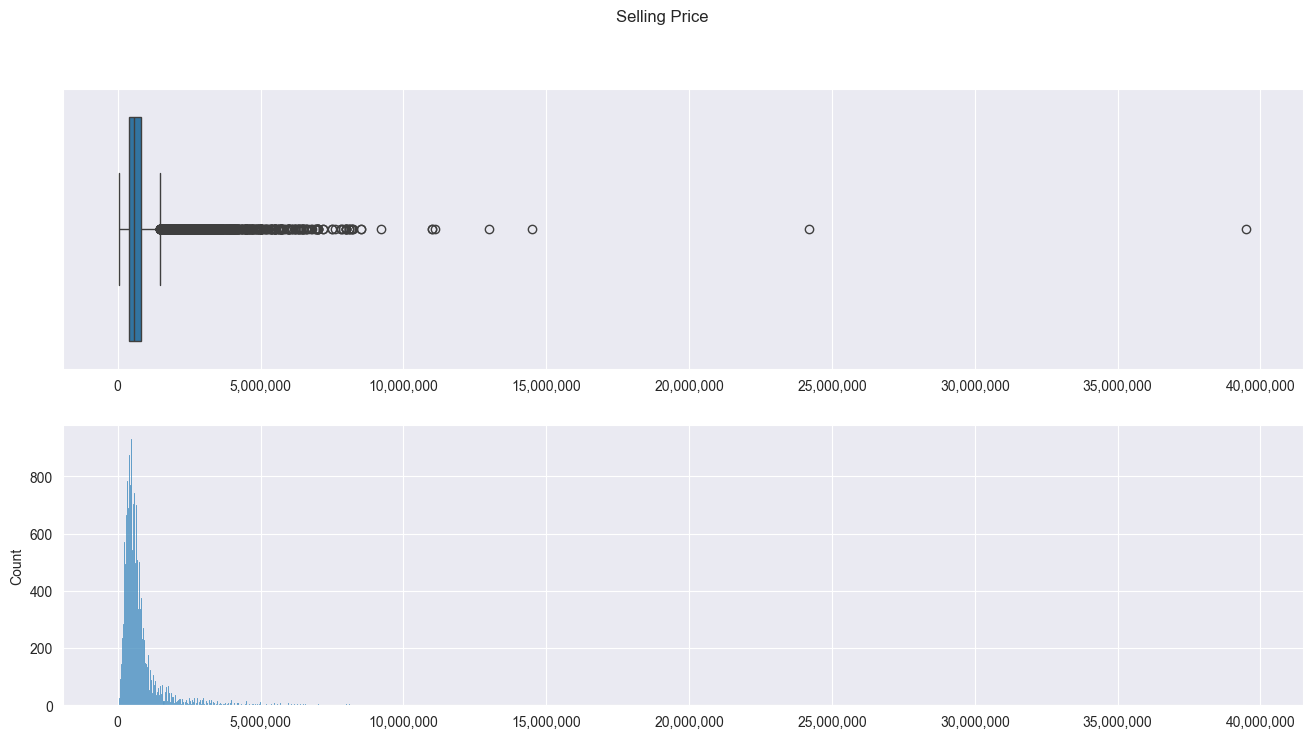

In [1573]:
fig, axis = plt.subplots(2, 1)

ax = sns.boxplot(
    data= df,
    x= "selling_price",
    ax= axis[0]
)

ax.set_xlabel("")

axis_formatter(ax, "x")

ax = sns.histplot(
    data= df,
    x= "selling_price",
    ax= axis[1]
)

ax.set_xlabel("")

axis_formatter(ax, "x")

plt.suptitle("Selling Price")

plt.show()

In [1574]:
q1, q2, q3 = df["selling_price"].quantile([0.25, 0.50, 0.75])
iqr = q3 - q1 # Inter Quantile Range
upper_bound = q3 + (iqr * 1.5) # Üst bıyık
lower_bound = 0 # alt bıyık

print(f"Skewness             : {df["selling_price"].skew():.5f}")
print(f"Kurtosis             : {df["selling_price"].kurt():.5f}")
print(f"Inter Quantile Range : {iqr}")
print(f"Upper Bound          : {upper_bound}")
print(f"Lower Bound          : {lower_bound}")

Skewness             : 10.10891
Kurtosis             : 284.27092
Inter Quantile Range : 440000.0
Upper Bound          : 1485000.0
Lower Bound          : 0


In [1575]:
# Hedef değişken(selling_price) sağa çarpık(Right-Skewed) bir dağılım izlemektedir.

# Değişken dağılımı grafiğin solunda, düşük değerlerde yoğunlaşmış olup,
# aşırı yüksek değerler, dağılımın sağ tarafında uzun bir kuyruk oluşturmaktadır.

# Bu dağılımın yorumlanmasını ve analizini zorlaştırmaktadır.

# Bu nedenle, analizin daha analşılır olması adına kopya bir veri seti oluşturulmuş,
# ve ilgili aşırı uç değerler bu veri setinden çıkarılmıştır.

# Orijinal veri seti korunmuş olup,
# aykırı değerler verilerin ön işlenme (Preprocessing) kısmında ele alnacaktır

In [1576]:
df_eda = df.copy()

In [1577]:
df_eda = df_eda[df_eda["selling_price"] != 39500000]
df_eda = df_eda[df_eda["selling_price"] != 24200000]

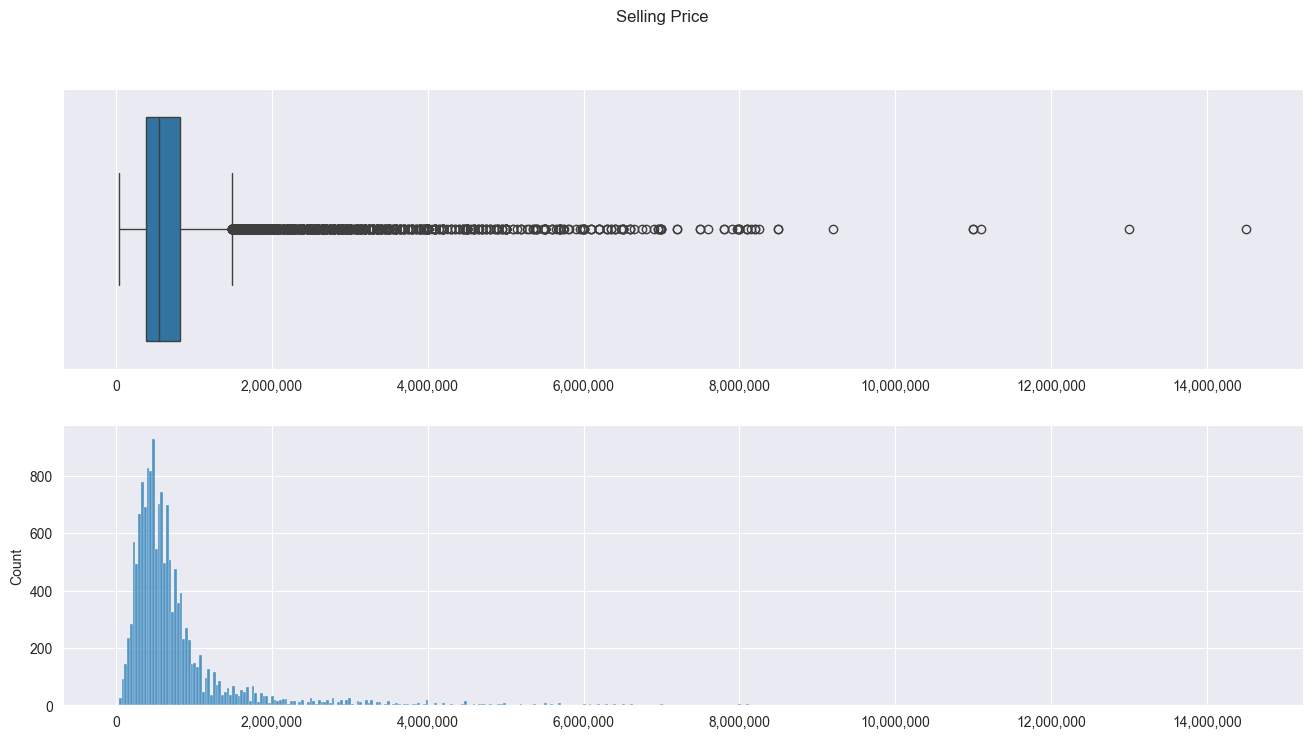

In [1578]:
fig, axis = plt.subplots(2, 1)

ax = sns.boxplot(
    data= df_eda,
    x= "selling_price",
    ax= axis[0]
)

ax.set_xlabel("")

axis_formatter(ax, "x")

ax = sns.histplot(
    data= df_eda,
    x= "selling_price",
    ax= axis[1]
)

ax.set_xlabel("")

axis_formatter(ax, "x")

plt.suptitle("Selling Price")

plt.show()

In [1579]:
q1, q2, q3 = df_eda["selling_price"].quantile([0.25, 0.50, 0.75])
iqr = q3 - q1 # Inter Quantile Range
upper_bound = q3 + (iqr * 1.5) # Üst bıyık
lower_bound = 0 # alt bıyık

print(f"Skewness             : {df_eda["selling_price"].skew():.5f}")
print(f"Kurtosis             : {df_eda["selling_price"].kurt():.5f}")
print(f"Inter Quantile Range : {iqr}")
print(f"Upper Bound          : {upper_bound}")
print(f"Lower Bound          : {lower_bound}")

Skewness             : 4.77135
Kurtosis             : 34.74614
Inter Quantile Range : 440000.0
Upper Bound          : 1485000.0
Lower Bound          : 0


In [1580]:
target_count = len(df_eda)
outlier_count = (df_eda["selling_price"] > 1485000).sum()

percentage = outlier_count / target_count

print(f"Total observations:  : {target_count}")
print(f"Outlier observations : {outlier_count}")
print(f"Outlier percentage   : {percentage:.2%}")

Total observations:  : 15240
Outlier observations : 1369
Outlier percentage   : 8.98%


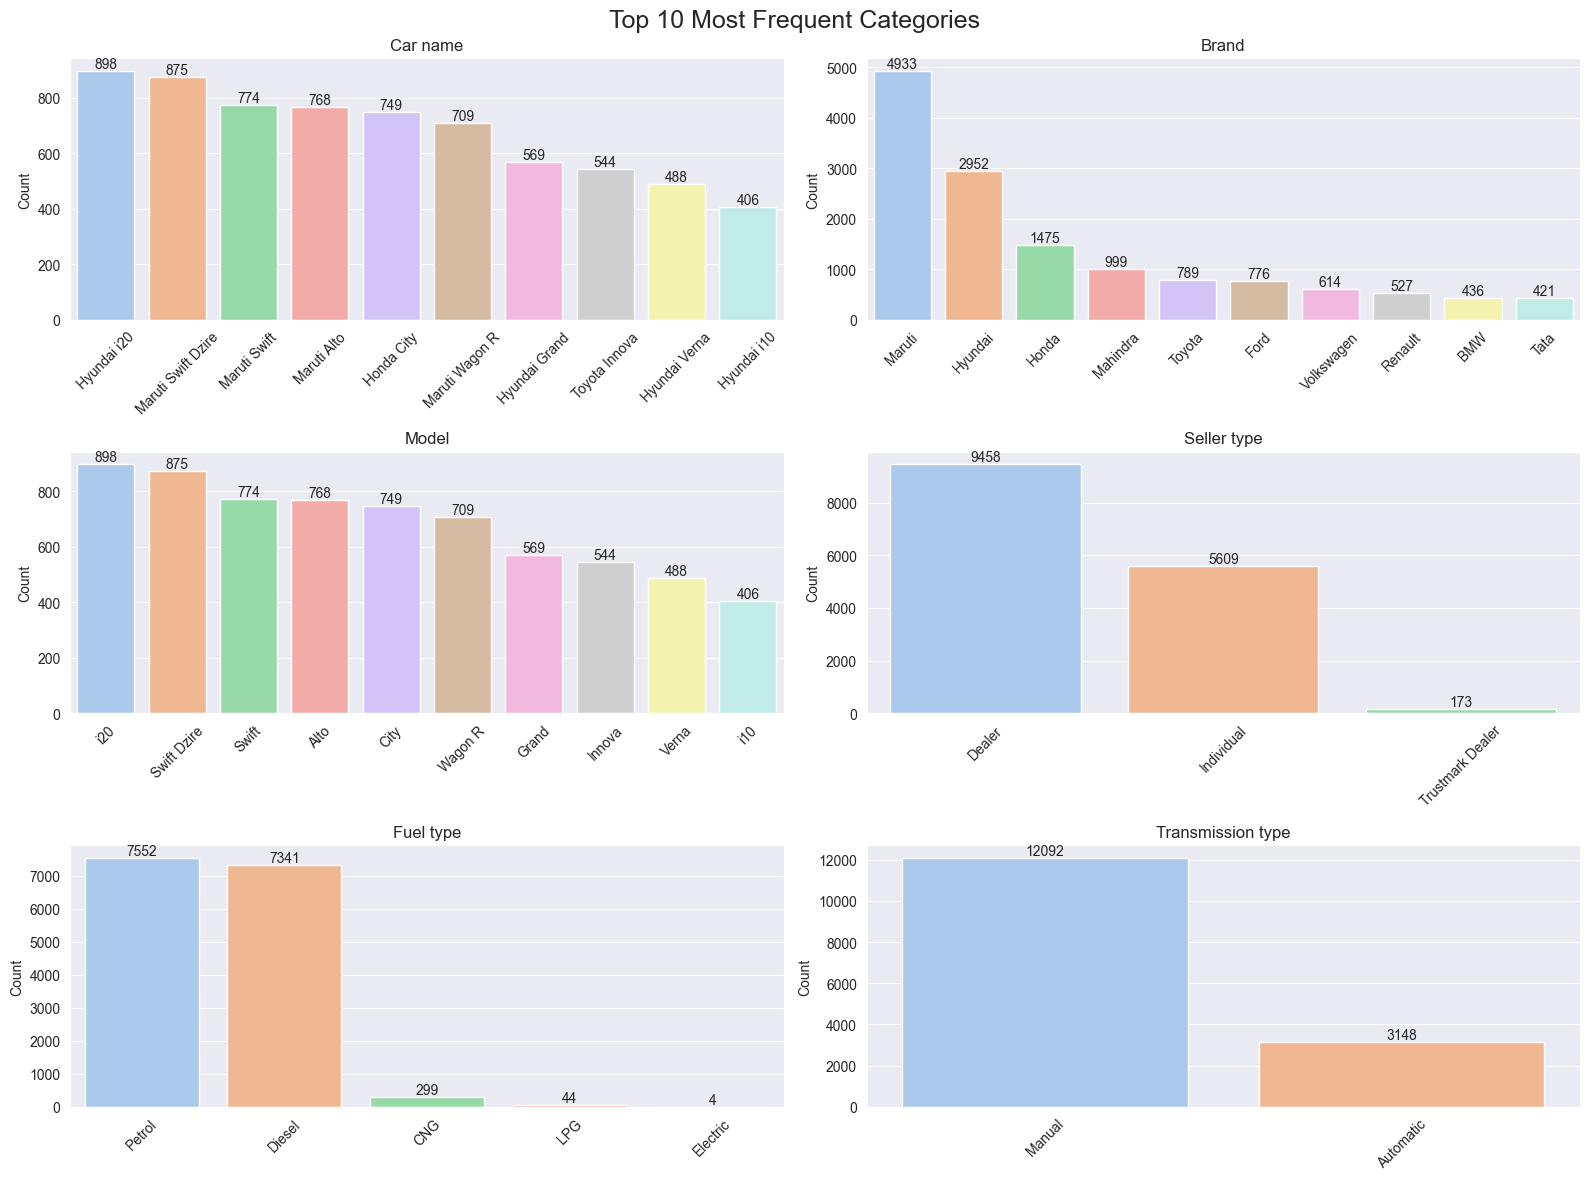

In [1581]:
columns = object_columns(df_eda)

col = 2
row = ceil(len(columns) / col)

fig, axis = plt.subplots(row, col, figsize = (16, row * 4))
axis = axis.ravel()

for index, column in enumerate(columns):
    sns.countplot(
        data= df_eda,
        x= column,
        order= df_eda[column].value_counts().head(10).index,
        palette= "pastel",
        ax= axis[index]
    )

    for container in axis[index].containers:
        axis[index].bar_label(container)

    axis[index].tick_params(axis = "x", rotation = 45)
    axis[index].set_title(column.replace("_", " ").capitalize())
    axis[index].set_xlabel("")
    axis[index].set_ylabel("Count")


plt.suptitle("Top 10 Most Frequent Categories", fontsize = 18)
plt.tight_layout()
plt.show()


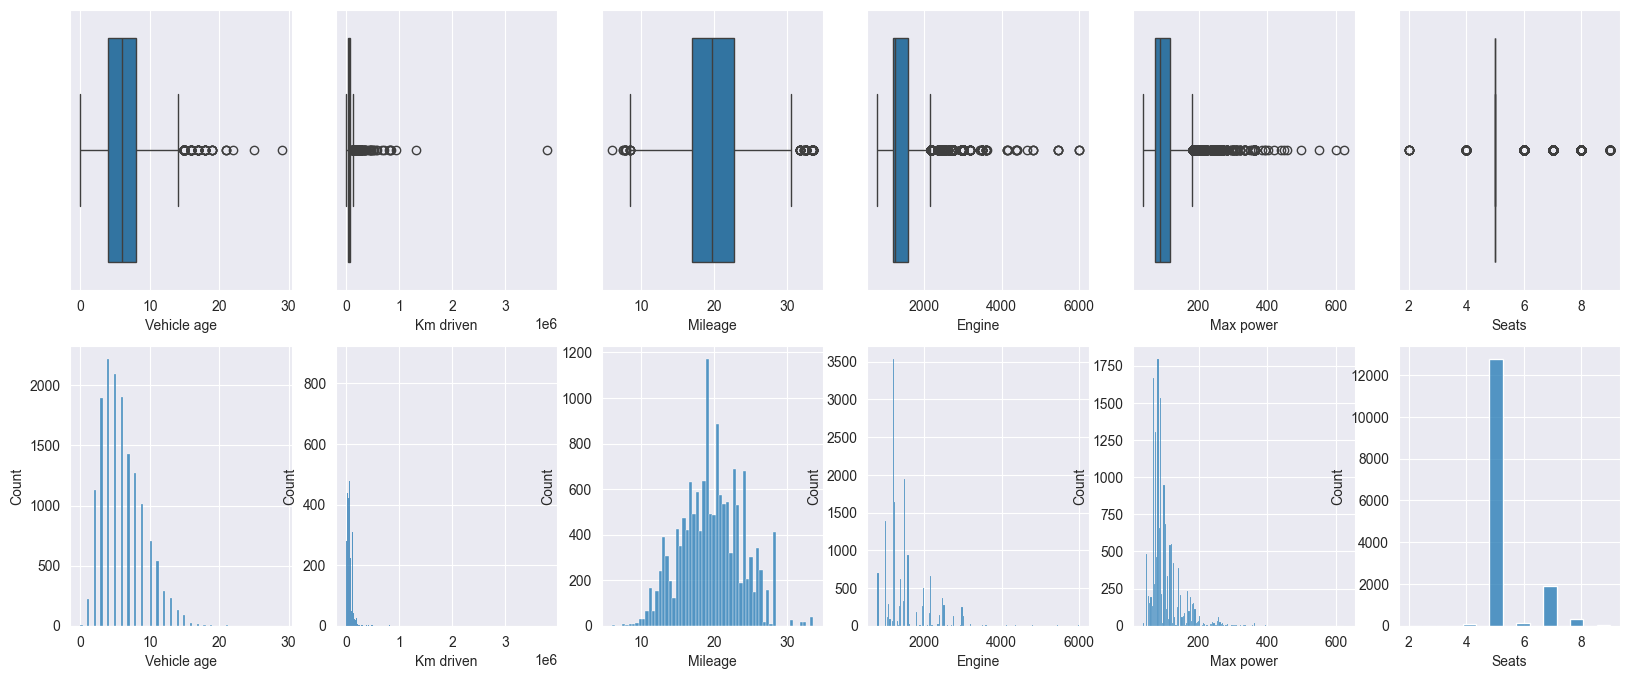

In [1582]:
columns = numeric_columns(df_eda)

row = 2
col = len(columns)

fig, axis = plt.subplots(row, col, figsize = (20, 8))


for index ,column in enumerate(columns):
    ax = sns.boxplot(
        data= df_eda,
        x= column,
        ax= axis[0, index]
    )

    ax.set_xlabel(f"{column.replace("_", " ").capitalize()}")
    
    ax = sns.histplot(
        data= df_eda,
        x= column,
        ax= axis[1, index]
    )

    ax.set_xlabel(f"{column.replace("_", " ").capitalize()}")



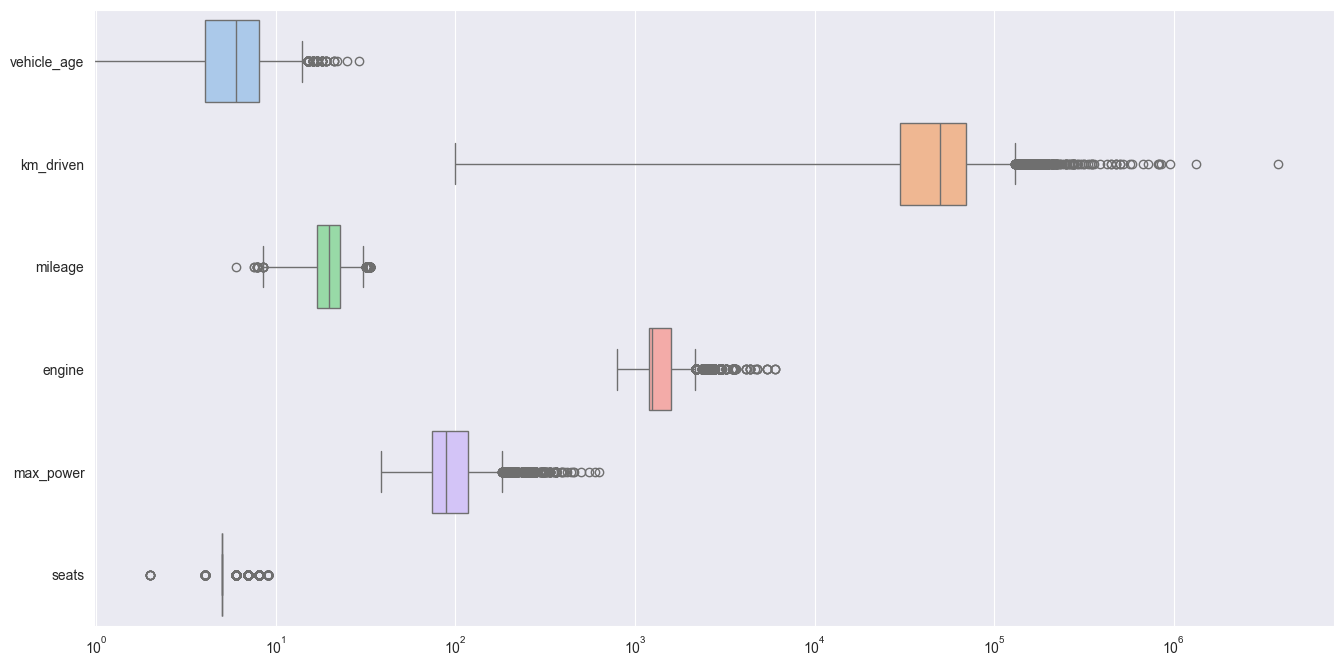

In [1583]:
columns = numeric_columns(df_eda)

ax = sns.boxplot(
    data= df_eda[columns],
    orient= "h",
    palette= "pastel"
)

ax.set_xscale("log")

plt.show()

In [1584]:
columns = numeric_columns(df)

for column in columns:
    print(f"Skewness of {column.replace("_", " ").capitalize()} : {df[column].skew()}")

Skewness of Vehicle age : 0.8314844372971378
Skewness of Km driven : 28.229362510559397
Skewness of Mileage : 0.10997521240909482
Skewness of Engine : 1.6692563240953544
Skewness of Max power : 2.4865246992151504
Skewness of Seats : 2.0905649607978622


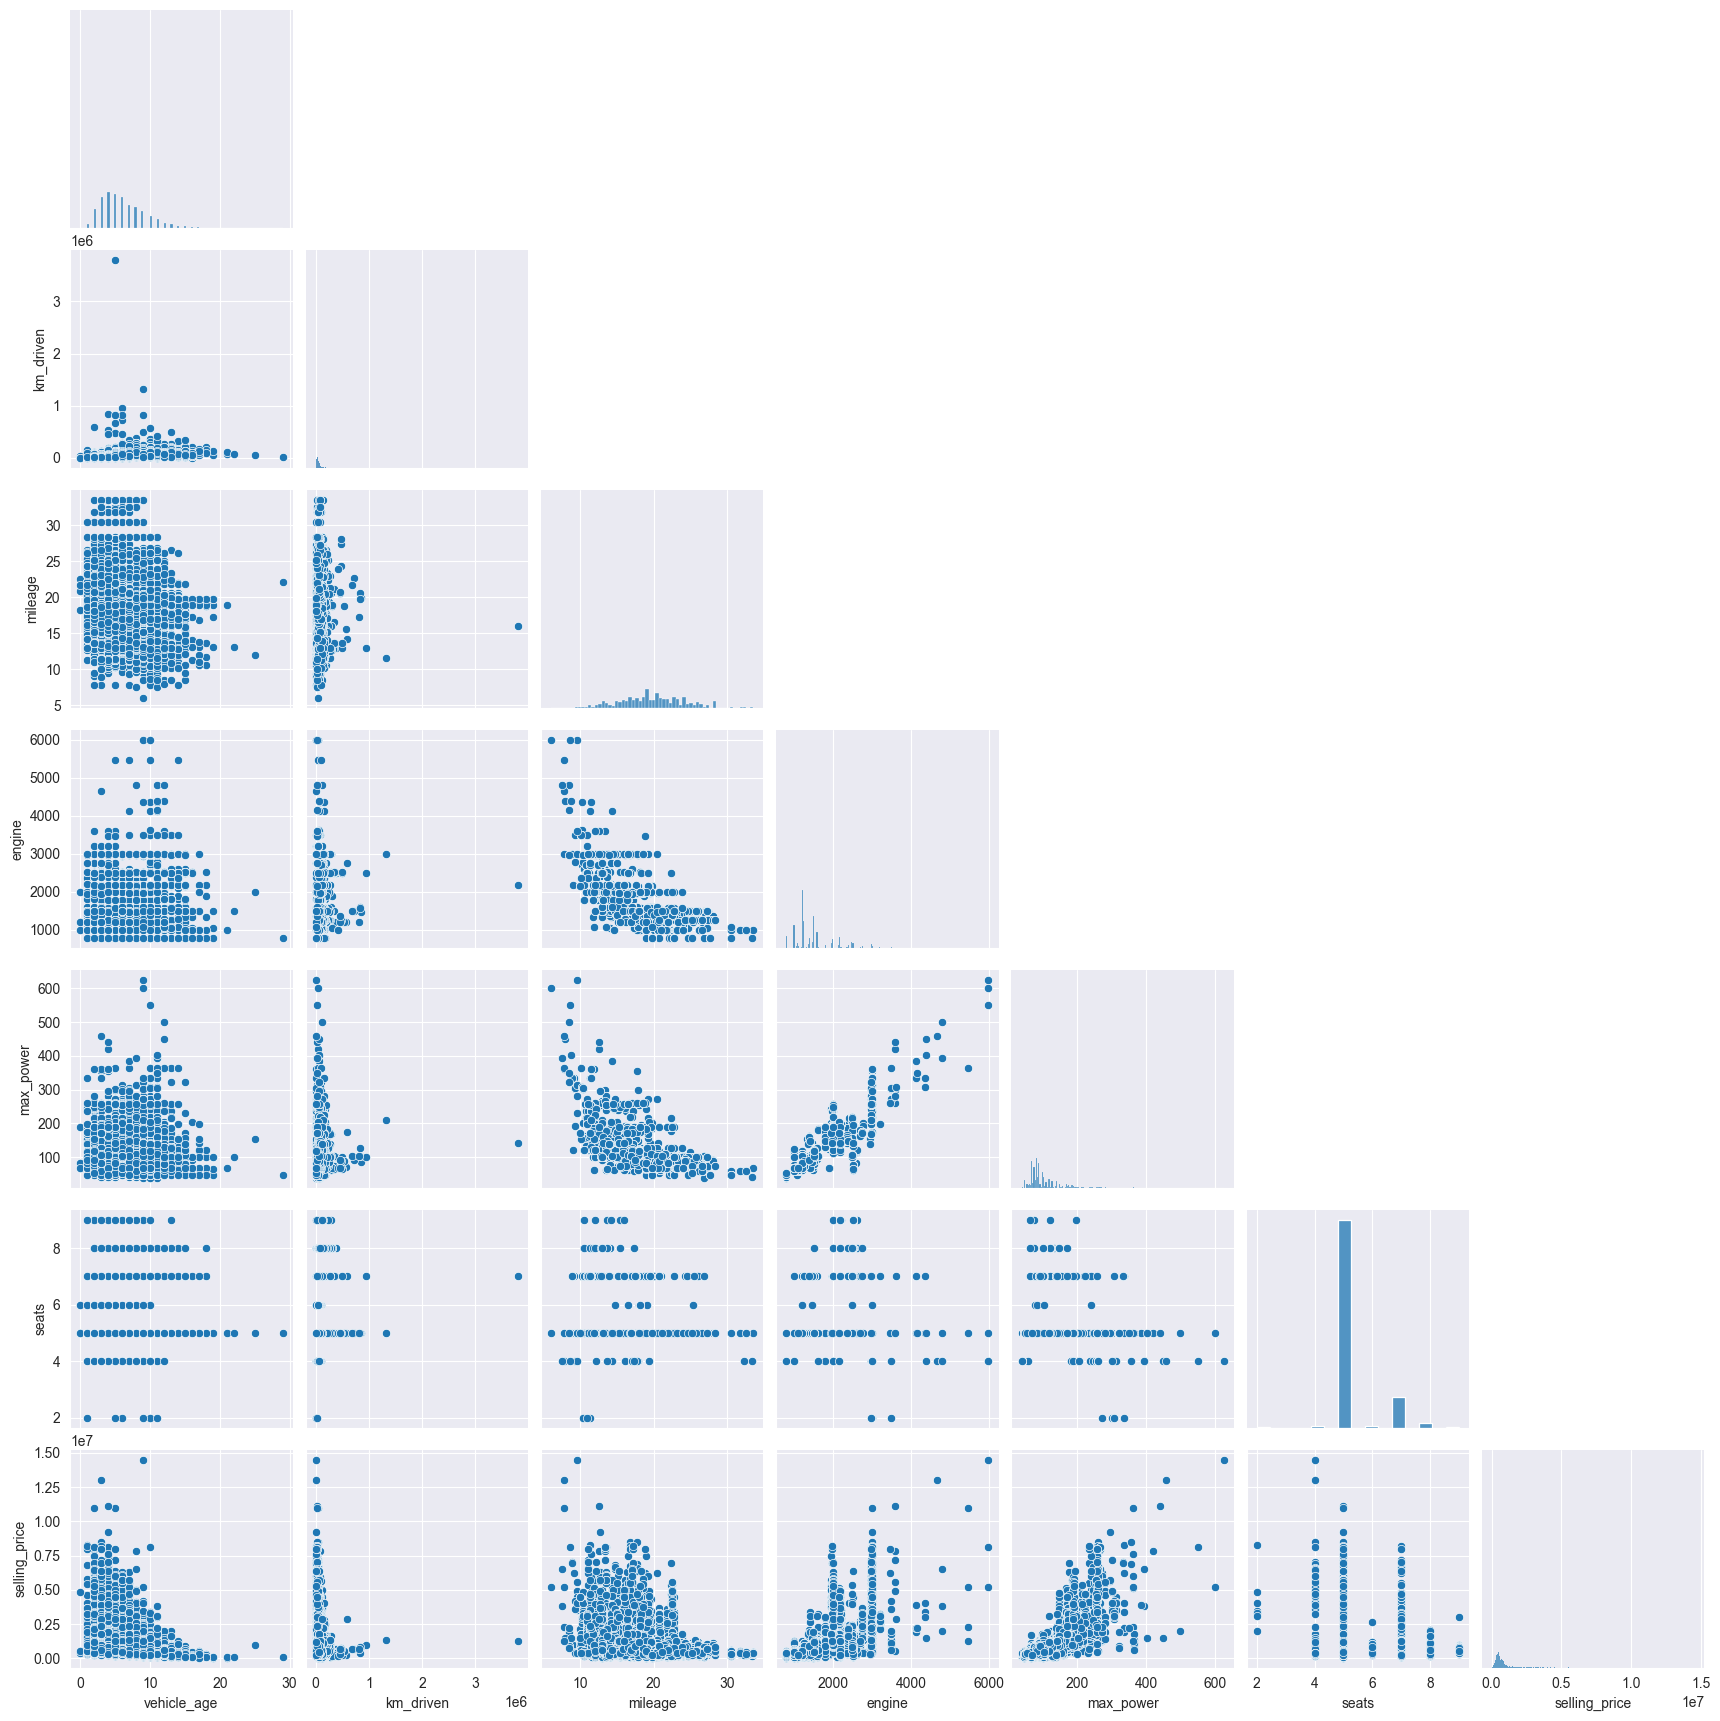

In [1585]:
sns.pairplot(df_eda, corner= True)
plt.show()

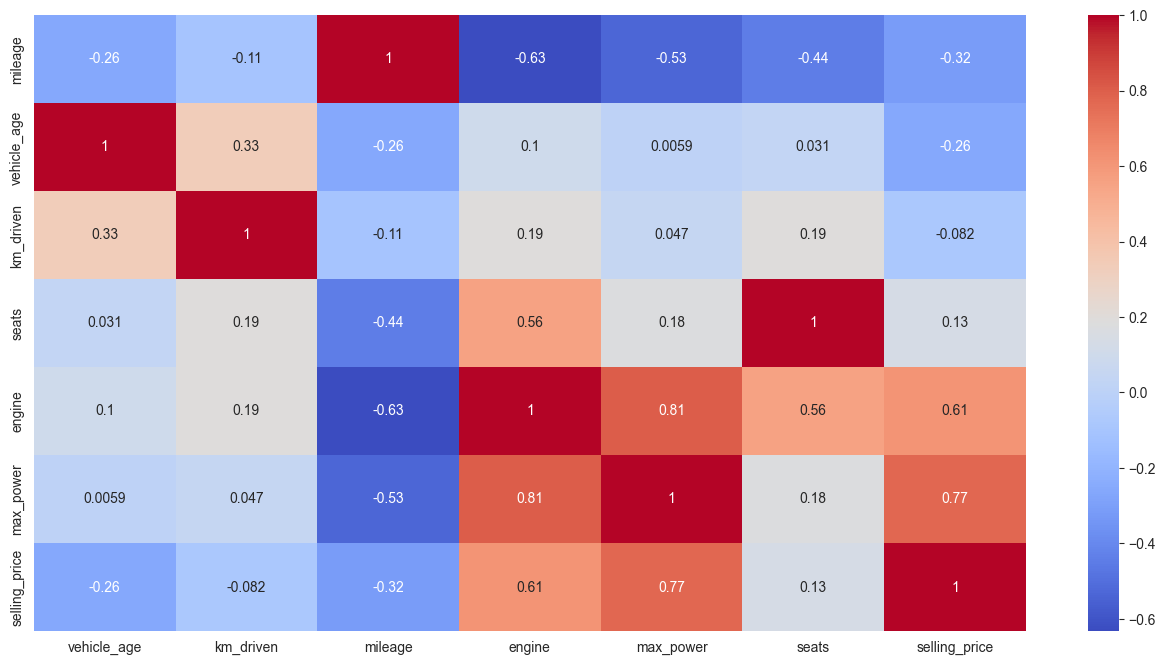

In [1586]:
corr = df_eda.corr(numeric_only= True).sort_values(by= "selling_price")
sns.heatmap(corr, cmap= "coolwarm", annot= True)

plt.show()

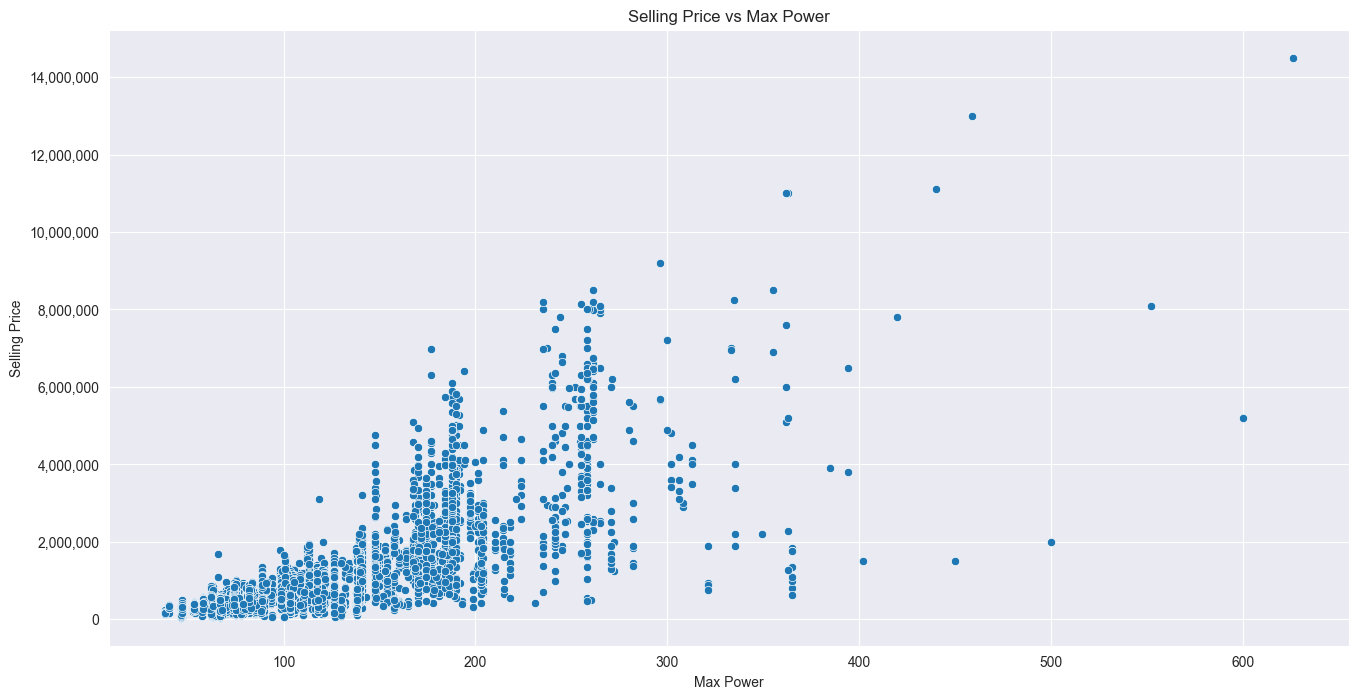

In [1587]:
ax = sns.scatterplot(
    data= df_eda,
    x= "max_power",
    y= "selling_price"
)

ax.set_title("Selling Price vs Max Power")
ax.set_ylabel("Selling Price")
ax.set_xlabel("Max Power")

axis_formatter(ax, "y")

plt.show()

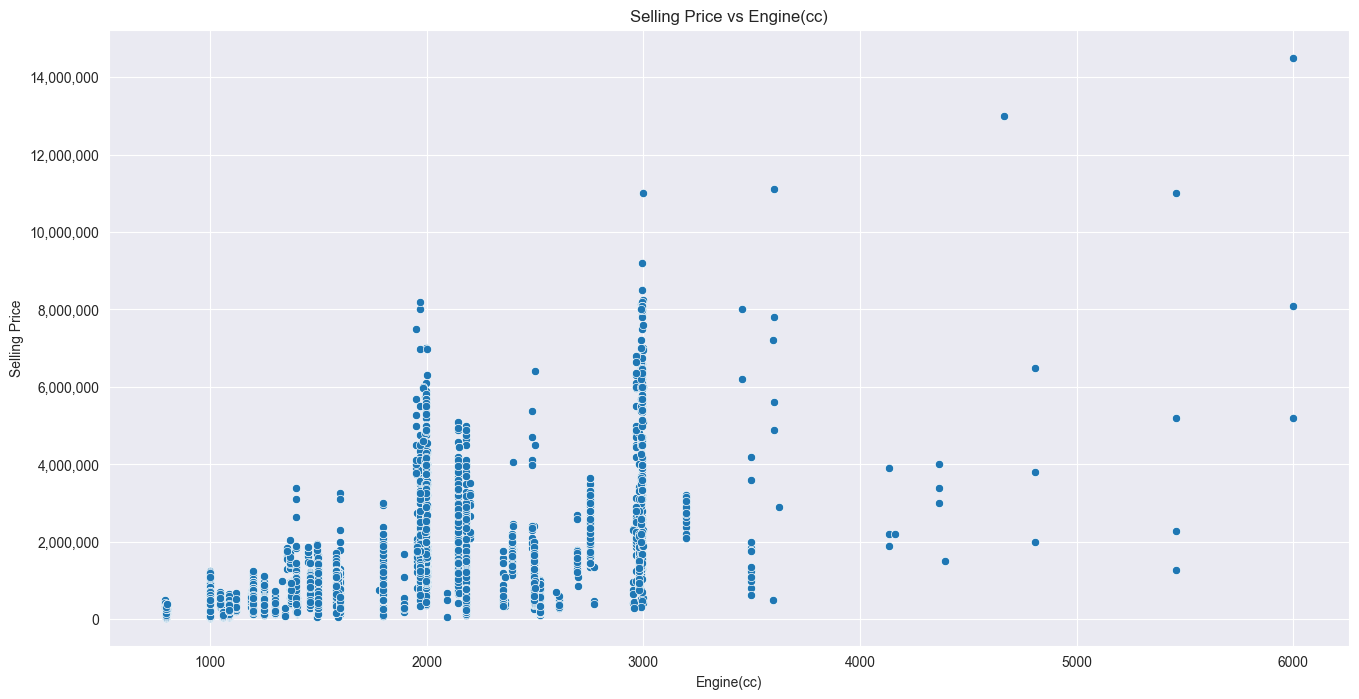

In [1588]:
ax = sns.scatterplot(
    data= df_eda,
    x= "engine",
    y= "selling_price"
)

ax.set_title("Selling Price vs Engine(cc)")
ax.set_ylabel("Selling Price")
ax.set_xlabel("Engine(cc)")

axis_formatter(ax, "y")

plt.show()

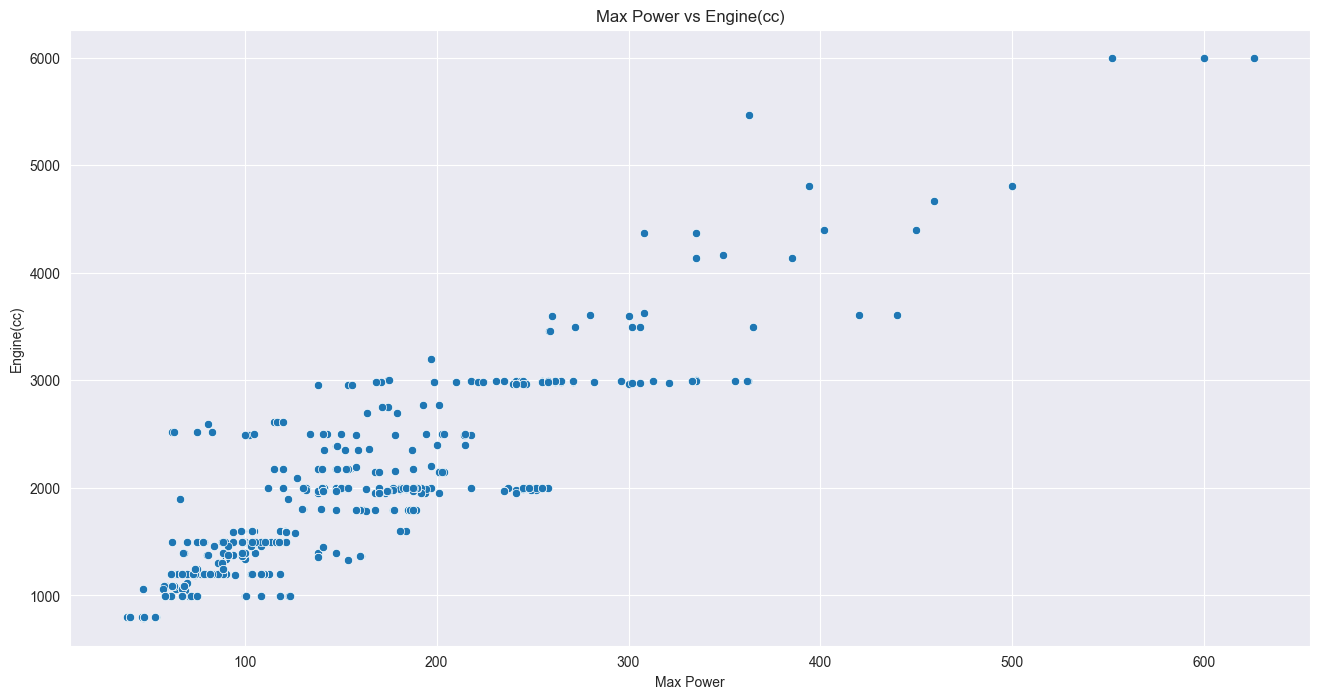

In [1589]:
sns.scatterplot(
    data= df_eda,
    x= "max_power",
    y= "engine"
)

plt.title("Max Power vs Engine(cc)")
plt.xlabel("Max Power")
plt.ylabel("Engine(cc)")


plt.show()

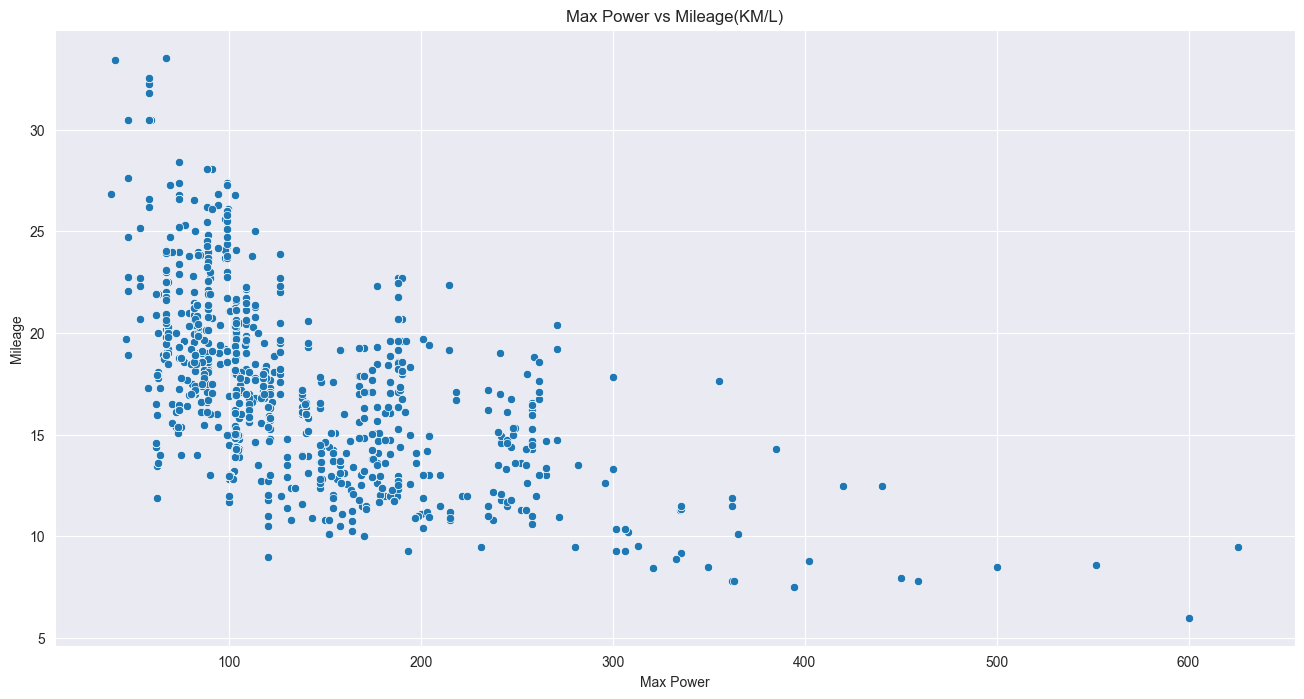

In [1590]:
sns.scatterplot(
    data= df_eda,
    x= "max_power",
    y= "mileage"
)

plt.title("Max Power vs Mileage(KM/L)")
plt.xlabel("Max Power")
plt.ylabel("Mileage")


plt.show()

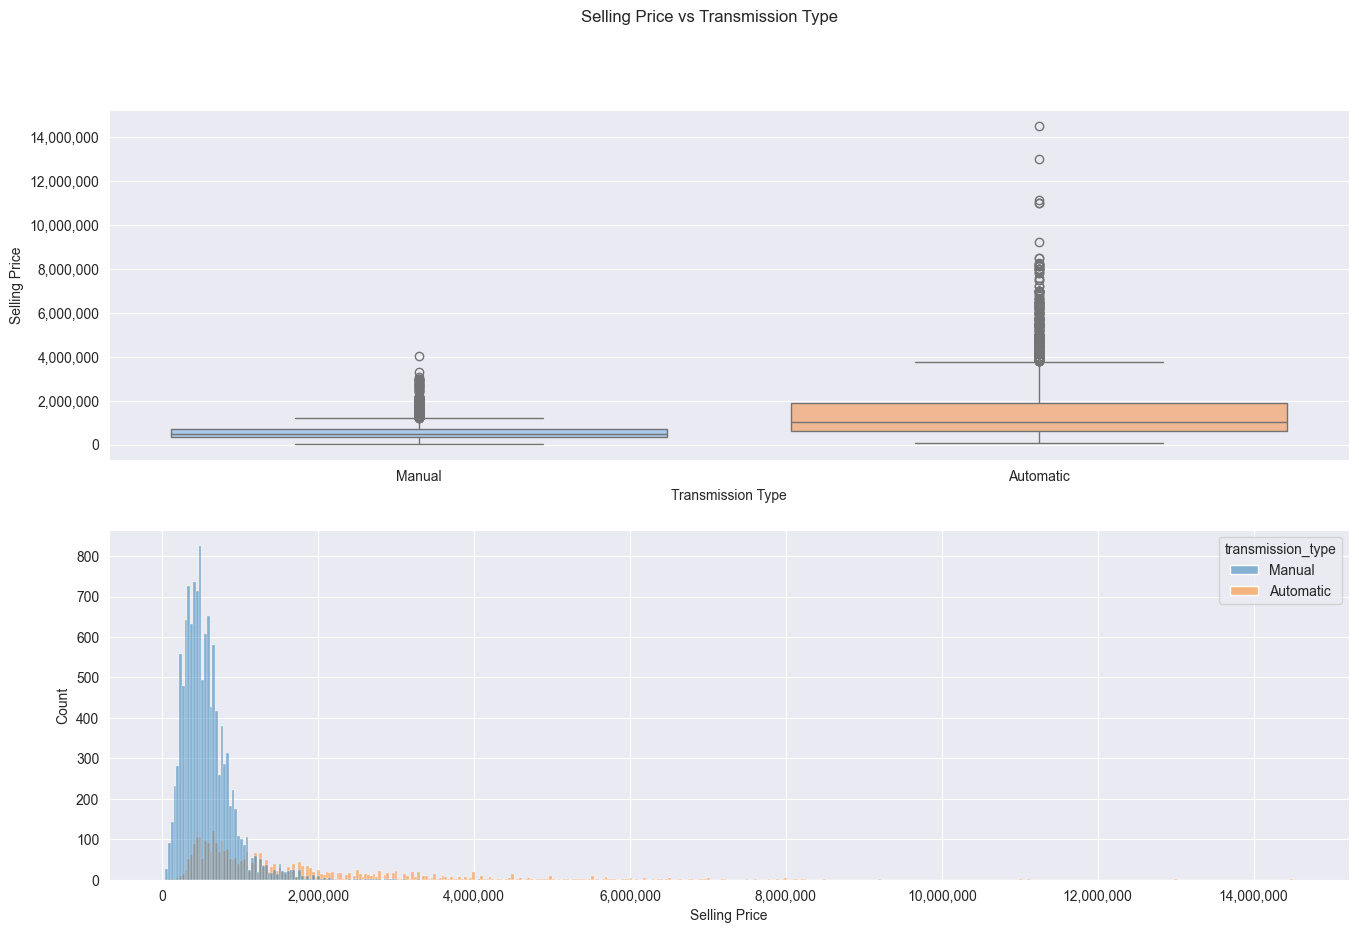

In [1591]:
fig, axis = plt.subplots(2, 1, figsize = (16, 10))

ax = sns.boxplot(
    data= df_eda,
    x= "transmission_type",
    y= "selling_price",
    palette= "pastel",
    ax= axis[0]
)


ax.set_ylabel("Selling Price")
ax.set_xlabel("Transmission Type")

axis_formatter(ax, "y")

ax = sns.histplot(
    data= df_eda,
    x = "selling_price",
    hue= "transmission_type",
    ax= axis[1]
)

ax.set_xlabel("Selling Price")

axis_formatter(ax, "x")

plt.suptitle("Selling Price vs Transmission Type")
plt.show()

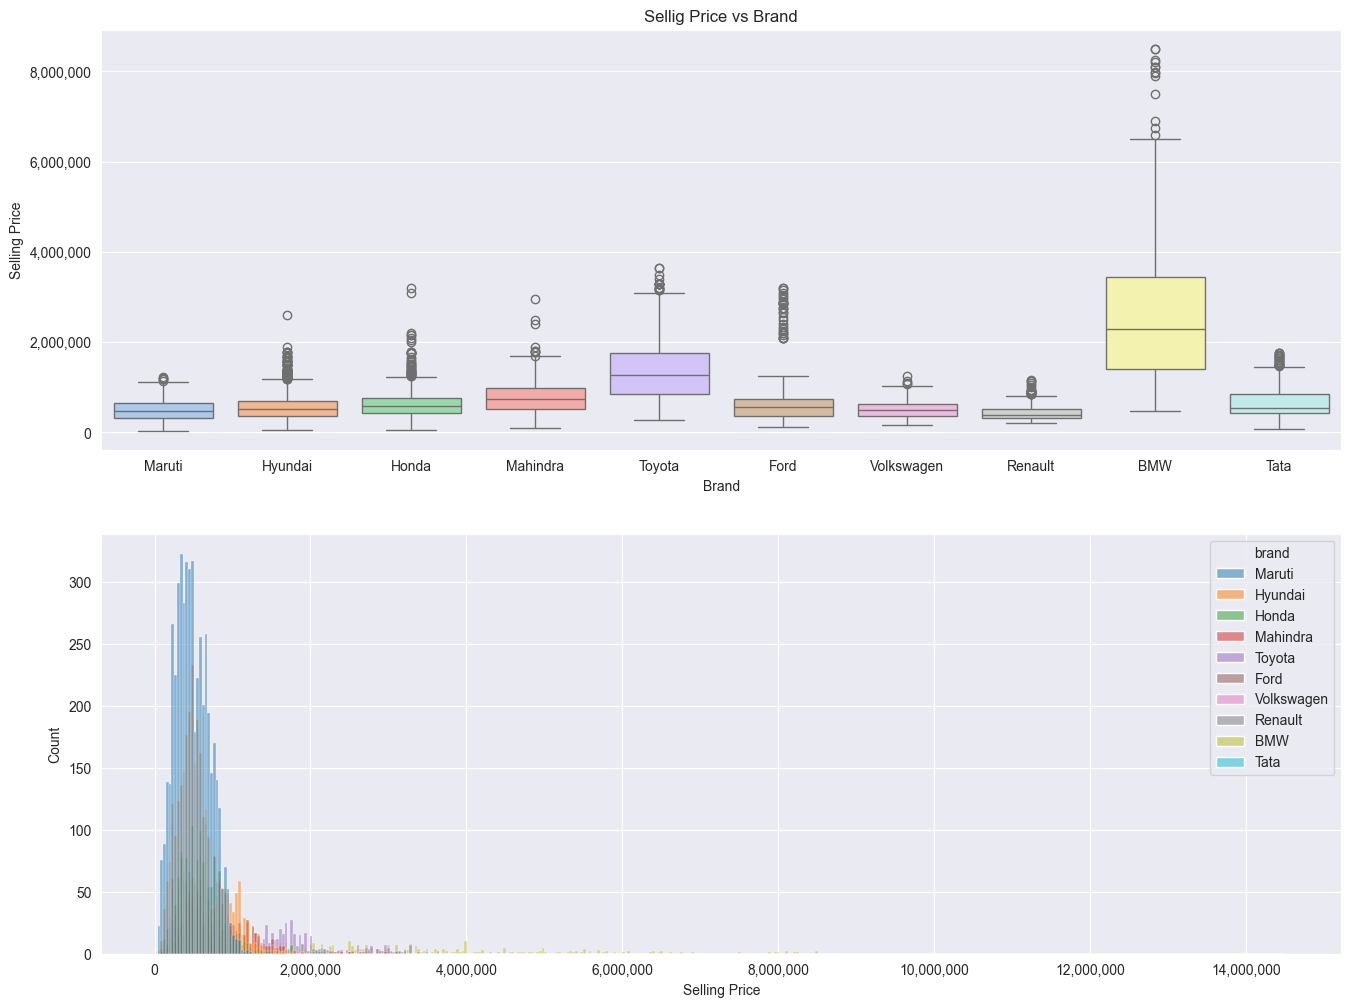

In [1592]:
fig, axis = plt.subplots(2, 1, figsize = (16, 12))
axis = axis.ravel()

ax = sns.boxplot(
    data= df_eda,
    x= "brand",
    y= "selling_price",
    order= df_eda["brand"].value_counts().head(10).index,
    palette= "pastel",
    ax= axis[0]
)

ax.set_title("Sellig Price vs Brand")
ax.set_ylabel("Selling Price")
ax.set_xlabel("Brand")

axis_formatter(ax, "y")



ax = sns.histplot(
    data= df_eda,
    x = "selling_price",
    hue= "brand",
    hue_order= df_eda["brand"].value_counts().head(10).index,
    ax= axis[1]
)

ax.set_xlabel("Selling Price")


axis_formatter(ax, "x")

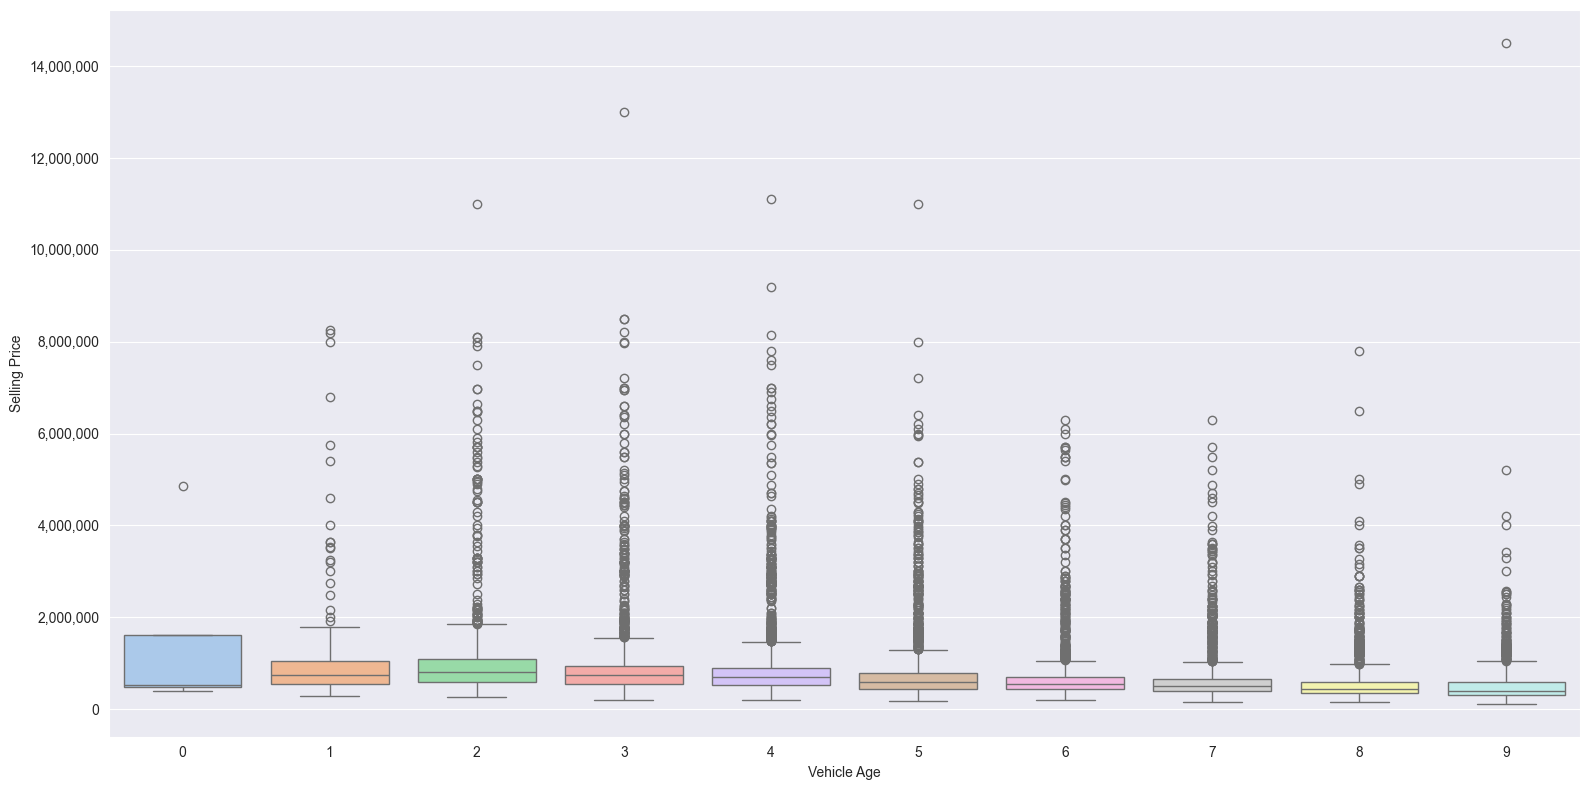

In [1593]:
ax = sns.boxplot(
    data= df_eda,
    x= "vehicle_age",
    y= "selling_price",
    order= df_eda["vehicle_age"].sort_index().head(10).index,
    palette= "pastel"
)

ax.set_ylabel("Selling Price")
ax.set_xlabel("Vehicle Age")

axis_formatter(ax, "y")

plt.tight_layout()

In [1594]:
# Çıkarımlar

# Hedef değiken(Target), sağa çarpık(Right-Skewed) bir dağılıma sahiptir.

# Değişken dağılımı grafiğn solunda, düşük değerlerde yoğunlaşmış olup,
# aşırı yüksek değerler, dağılımın sağında uzun bir kuyruk olmuşturmaktadır

# Veri setinde,belirgin şekilde en fazla araca sahip marka Maruti olduğu görülmektedir.

# Manuel vitesli araçların sayısı açık ara otomatik vitesli araçlara nazaran daha fazla olduğu görülmektedir.

# Araçların yarısının yakıt olarak Petrol kullanığı görülürken, araçların diğer yarısının Dizel yakıt kullandığı görülmektedir.

# Araç satışlarının yarısından fazlası Yetkili Bayiiler(Dealer) tarafından gerçekleştirilirken,
# satışların geri kalanı araç sahipleri(Individual) kendileri tarafından gerçekleştirilimektedir.

# En fazla satış adedine ulaşan model 920 satışla Hyundai i20 olurken,
# onu 890 satışla Maruti Swift Dzire takip etmektedir.

# Araçların satış fiyatı(Selling Price) yükseldikçe, araçların motor gücü(Max Power(BHP)) genel itibari ile artmaktadır.

# Araçların motor gücü(Max Power(BHP)) arttıkça, araçların bir litre yakıt ile gidebildikleri mesafe(Mileage(Km/L)) azalmaktadır.

# Marka bazında satış fiyatları incelendiğinde , BMW markasının satış fiyatının genel itibariyle diğer marklara kıyasla
# belirgin şekilde daha yüksek olduğu gözlemlenmektedir.

# Yeni araçların satış fiyatı eski araç kıysla genel olarak daha yüksek fiyatlara satılmasında rağmen,
# bazı eski araçların, sıfır araçların satış fiyatından daha yüksek fiyata satıldığı gözlemlenmektedir.

# Preprocessing

In [1595]:
X = df.drop("selling_price", axis= 1)
y = df["selling_price"]

In [1596]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

In [1597]:
columns = object_columns(X)

df[columns].nunique()

car_name             121
brand                 32
model                120
seller_type            3
fuel_type              5
transmission_type      2
dtype: int64

In [1598]:
ohe_columns = ["seller_type", "fuel_type", "transmission_type"]
freq_columns = ["car_name", "brand", "model"]

In [1599]:
def frequency_encoding(X_train, X_test):
    for column in freq_columns:
        freq = X_train[column].value_counts() / len(X_train)
        X_train[f"{column}_freq"] = X_train[column].map(freq)
        X_test[f"{column}_freq"] = X_test[column].map(freq)

        freq_mean = freq.mean()
        X_test[f"{column}_freq"] = X_test[f"{column}_freq"].fillna(freq_mean)

    X_train.drop(freq_columns, axis = 1, inplace= True)
    X_test.drop(freq_columns, axis = 1, inplace= True)

    return X_train, X_test

In [1600]:
X_train, X_test = frequency_encoding(X_train, X_test)

In [1601]:
X_train

,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,car_name_freq,brand_freq,model_freq
1525,10,80000,Individual,Diesel,Manual,20.54,1598,103.60,5,0.02,0.04,0.02
13708,8,55572,Dealer,Petrol,Automatic,13.70,1798,157.75,5,0.01,0.02,0.01
6013,3,43000,Dealer,Diesel,Manual,24.00,1186,73.97,5,0.04,0.19,0.04
215,8,62000,Dealer,Diesel,Manual,22.70,1498,89.84,5,0.02,0.05,0.02
14495,7,110000,Individual,Diesel,Manual,20.00,1399,68.05,5,0.02,0.05,0.02
...,...,...,...,...,...,...,...,...,...,...,...,...
5213,4,55000,Individual,Diesel,Manual,16.36,2179,140.00,7,0.02,0.07,0.02
13553,8,67000,Dealer,Petrol,Manual,15.04,1598,103.60,5,0.02,0.04,0.02
5416,5,27200,Dealer,Diesel,Manual,24.30,1248,88.50,5,0.02,0.32,0.02
862,2,10000,Individual,Petrol,Manual,22.70,799,53.64,5,0.00,0.01,0.00


In [1602]:
X_test

,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,car_name_freq,brand_freq,model_freq
10310,1,4713,Trustmark Dealer,Petrol,Manual,17.00,1197,110.00,5,0.00,0.07,0.00
12687,5,30000,Dealer,Petrol,Manual,22.30,799,53.26,5,0.02,0.03,0.02
11838,5,119775,Dealer,Diesel,Automatic,16.38,1995,182.46,5,0.00,0.19,0.00
10255,7,57000,Dealer,Diesel,Automatic,17.68,1968,174.33,5,0.00,0.01,0.00
14763,4,63000,Individual,Diesel,Manual,24.52,1248,88.50,7,0.02,0.32,0.02
...,...,...,...,...,...,...,...,...,...,...,...,...
4266,3,70000,Individual,Diesel,Manual,14.24,2755,174.50,7,0.01,0.05,0.01
12037,3,20067,Trustmark Dealer,Petrol,Manual,21.63,998,67.04,5,0.02,0.32,0.02
2755,5,27000,Dealer,Diesel,Automatic,14.69,2993,258.00,5,0.01,0.03,0.01
9485,7,58000,Dealer,Diesel,Manual,25.80,1498,98.60,5,0.02,0.10,0.02


In [1603]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

encoder = OneHotEncoder()

In [1604]:
def ohe_encoding(X_train, X_test):
    transformer = ColumnTransformer(
        transformers= [
            ("One-Hot", OneHotEncoder(drop= "first", handle_unknown= "ignore"), ohe_columns)
        ], remainder= "passthrough"
    )

    X_train_transformed = transformer.fit_transform(X_train)
    X_test_transformed = transformer.transform(X_test)

    encoded_cols = transformer.get_feature_names_out()

    X_train = pd.DataFrame(
        data= X_train_transformed,
        columns= encoded_cols,
        index= X_train.index
    )

    X_test = pd.DataFrame(
        data= X_test_transformed,
        columns= encoded_cols,
        index= X_test.index
    )

    return X_train, X_test

In [1605]:
X_train, X_test = ohe_encoding(X_train, X_test)

In [1606]:
X_train.head()

,One-Hot__seller_type_Individual,One-Hot__seller_type_Trustmark Dealer,One-Hot__fuel_type_Diesel,One-Hot__fuel_type_Electric,One-Hot__fuel_type_LPG,One-Hot__fuel_type_Petrol,One-Hot__transmission_type_Manual,remainder__vehicle_age,remainder__km_driven,remainder__mileage,remainder__engine,remainder__max_power,remainder__seats,remainder__car_name_freq,remainder__brand_freq,remainder__model_freq
1525,1.00,0.00,1.00,0.00,0.00,0.00,1.00,10.00,80000.00,20.54,1598.00,103.60,5.00,0.02,0.04,0.02
13708,0.00,0.00,0.00,0.00,0.00,1.00,0.00,8.00,55572.00,13.70,1798.00,157.75,5.00,0.01,0.02,0.01
6013,0.00,0.00,1.00,0.00,0.00,0.00,1.00,3.00,43000.00,24.00,1186.00,73.97,5.00,0.04,0.19,0.04
215,0.00,0.00,1.00,0.00,0.00,0.00,1.00,8.00,62000.00,22.70,1498.00,89.84,5.00,0.02,0.05,0.02
14495,1.00,0.00,1.00,0.00,0.00,0.00,1.00,7.00,110000.00,20.00,1399.00,68.05,5.00,0.02,0.05,0.02


## Model Training

In [1607]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV

In [1608]:
def evaluate_model(X_train, X_test, y_train, y_test, model, params = None):
    if params is None:
        model.fit(X_train, y_train)

        predicts = model.predict(X_test)
    else:
        random = RandomizedSearchCV(
            estimator= model,
            param_distributions= params,
            scoring= "r2",
            cv= 5,
            n_jobs= -1
        )

        random.fit(X_train, y_train)

        print(f"Best Params\n{random.best_params_}\n")
        print(f"Best Estimator\n{random.best_estimator_}\n")

        predicts = random.predict(X_test)

    print(f"r2 Score : {r2_score(y_test, predicts):.2%}")
    print(f"Mean Squared Error : {mean_squared_error(y_test, predicts)}")
    print(f"Mean Absolute Error  : {mean_absolute_error(y_test, predicts)}")

In [1609]:
# Basit model eğitimi
model = AdaBoostRegressor(random_state= 42)

evaluate_model(X_train, X_test, y_train, y_test, model= model)

r2 Score : 62.23%
Mean Squared Error : 306506598955.6519
Mean Absolute Error  : 402776.14350997383


In [1610]:
params = {
    "n_estimators" : [50, 100, 200, 300],
    "learning_rate" : [0.1, 1, 3, 5, 10],
    "loss" : ['linear', 'square', 'exponential' ]
}

model = AdaBoostRegressor(random_state= 42)

evaluate_model(X_train, X_test, y_train, y_test, model= model, params= params)

Best Params
{'n_estimators': 200, 'loss': 'square', 'learning_rate': 0.1}

Best Estimator
AdaBoostRegressor(learning_rate=0.1, loss='square', n_estimators=200,
                  random_state=42)

r2 Score : 70.43%
Mean Squared Error : 239952754102.86942
Mean Absolute Error  : 262933.83543047315


In [1611]:
params = {
    "estimator__max_depth" : [3, 4, 5],
    "n_estimators" : [50, 100, 200, 300],
    "learning_rate" : [0.1, 1, 3, 5, 10],
    "loss" : ['linear', 'square', 'exponential' ]
}

model = AdaBoostRegressor(random_state= 42, estimator= DecisionTreeRegressor(random_state= 42))

evaluate_model(X_train, X_test, y_train, y_test, model= model, params= params)

Best Params
{'n_estimators': 50, 'loss': 'linear', 'learning_rate': 0.1, 'estimator__max_depth': 5}

Best Estimator
AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=5, random_state=42),
                  learning_rate=0.1, random_state=42)

r2 Score : 83.51%
Mean Squared Error : 133809281306.87836
Mean Absolute Error  : 153190.90327842004


In [1612]:
# Hedef değişkenin log dönüşümü ve model eğitimi
df_test_1 = df.copy()

In [1613]:
X = df_test_1.drop("selling_price", axis= 1)
y = df_test_1["selling_price"]

In [1614]:
y = np.log1p(y)

In [1615]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

In [1616]:
X_train, X_test = frequency_encoding(X_train, X_test)
X_train, X_test = ohe_encoding(X_train, X_test)

In [1617]:
model = AdaBoostRegressor(random_state= 42)

evaluate_model(X_train, X_test, y_train, y_test, model= model)

r2 Score : 81.57%
Mean Squared Error : 0.08370206906380576
Mean Absolute Error  : 0.23177811590107347


In [1618]:
params = {
    "n_estimators" : [50, 100, 200, 300],
    "learning_rate" : [0.1, 1, 3, 5, 10],
    "loss" : ['linear', 'square', 'exponential' ]
}

model = AdaBoostRegressor(random_state= 42)

evaluate_model(X_train, X_test, y_train, y_test, model= model, params= params)

Best Params
{'n_estimators': 200, 'loss': 'linear', 'learning_rate': 3}

Best Estimator
AdaBoostRegressor(learning_rate=3, n_estimators=200, random_state=42)

r2 Score : 82.53%
Mean Squared Error : 0.07938229940107093
Mean Absolute Error  : 0.22816987971708633


In [1619]:
params = {
    "estimator__max_depth" : [3, 4, 5],
    "n_estimators" : [50, 100, 200, 300],
    "learning_rate" : [0.1, 1, 3, 5, 10],
    "loss" : ['linear', 'square', 'exponential']
}

model = AdaBoostRegressor(random_state= 42, estimator= DecisionTreeRegressor(random_state= 42))
evaluate_model(X_train, X_test, y_train, y_test, model= model, params= params)

Best Params
{'n_estimators': 100, 'loss': 'exponential', 'learning_rate': 3, 'estimator__max_depth': 5}

Best Estimator
AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=5, random_state=42),
                  learning_rate=3, loss='exponential', n_estimators=100,
                  random_state=42)

r2 Score : 89.27%
Mean Squared Error : 0.04872718797516671
Mean Absolute Error  : 0.17632454533538777


In [ ]:
# Bağımsız değişkenlerin PowerTransofermer ile dönüşümü ve model eğitimi
df_test_2 = df.copy()

In [1621]:
X = df_test_2.drop("selling_price", axis= 1)
y = df_test_2["selling_price"]

In [1622]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

In [1623]:
from sklearn.preprocessing import PowerTransformer

pt_transformer = PowerTransformer(method= "yeo-johnson")

In [1624]:
pt_columns = numeric_columns(X_train)
pt_columns = pt_columns.drop("seats")
pt_columns

X_train[pt_columns] = pt_transformer.fit_transform(X_train[pt_columns])
X_test[pt_columns] = pt_transformer.transform(X_test[pt_columns])

In [1625]:
X_train, X_test = frequency_encoding(X_train, X_test)
X_train, X_test = ohe_encoding(X_train, X_test)

In [1626]:
model = AdaBoostRegressor(random_state= 42)

evaluate_model(X_train, X_test, y_train, y_test, model= model)

r2 Score : 62.19%
Mean Squared Error : 306777277279.87897
Mean Absolute Error  : 402824.5190053435


In [1627]:
params = {
    "n_estimators" : [50, 100, 200, 300],
    "learning_rate" : [0.1, 1, 3, 5, 10],
    "loss" : ['linear', 'square', 'exponential' ]
}

model = AdaBoostRegressor(random_state= 42)

evaluate_model(X_train, X_test, y_train, y_test, model= model, params= params)

Best Params
{'n_estimators': 100, 'loss': 'exponential', 'learning_rate': 0.1}

Best Estimator
AdaBoostRegressor(learning_rate=0.1, loss='exponential', n_estimators=100,
                  random_state=42)

r2 Score : 71.43%
Mean Squared Error : 231851542827.68222
Mean Absolute Error  : 231871.0626032528


In [1628]:
params = {
    "estimator__max_depth" : [3, 4, 5],
    "n_estimators" : [50, 100, 200, 300],
    "learning_rate" : [0.1, 1, 3, 5, 10],
    "loss" : ['linear', 'square', 'exponential']
}

model = AdaBoostRegressor(random_state= 42, estimator= DecisionTreeRegressor(random_state= 42))
evaluate_model(X_train, X_test, y_train, y_test, model= model, params= params)

Best Params
{'n_estimators': 100, 'loss': 'linear', 'learning_rate': 0.1, 'estimator__max_depth': 4}

Best Estimator
AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=4, random_state=42),
                  learning_rate=0.1, n_estimators=100, random_state=42)

r2 Score : 80.22%
Mean Squared Error : 160491705495.75696
Mean Absolute Error  : 185809.821653313
